# 1. Generate gridded EWH field from CSR, GFZ, JPL

In [1]:
import pathlib

import cartopy
import numpy as np

import sagea
from sagea.utils import TimeTool

"""define paths"""
dir_csr = pathlib.Path("/Volumes/WorkDrive/data/GRACE/L2_SH_products/GSM/CSR/RL06/BA01")
dir_gfz = pathlib.Path("/Volumes/WorkDrive/data/GRACE/L2_SH_products/GSM/GFZ/RL06/BA01")
dir_jpl = pathlib.Path("/Volumes/WorkDrive/data/GRACE/L2_SH_products/GSM/JPL/RL06/BA01")

path_gif48 = pathlib.Path("/Users/shuhao/PycharmProjects/SaGEA/data/auxiliary/GIF48.gfc")

path_TN14 = pathlib.Path("/Users/shuhao/PycharmProjects/SaGEA/data/L2_low_degrees/TN-14_C30_C20_SLR_GSFC.txt")

year_begin, year_end = 2002, 2020
lmax = 60
paths = [[], [], []]

for year in range(year_begin, year_end + 1):
    paths[0] += list(dir_jpl.glob(f"{year}/GSM-2*0600"))
    paths[1] += list(dir_gfz.glob(f"{year}/GSM-2*0600"))
    paths[2] += list(dir_csr.glob(f"{year}/GSM-2*0600"))

for path in paths:
    path.sort()

shc_gif48 = sagea.SHC.io.from_gfc(path_gif48, lmax=lmax)

grid_list = []
for i in range(len(paths)):
    dates_begin, dates_end = TimeTool.match_dates_from_name(paths[i])
    dates = TimeTool.get_average_dates(dates_begin, dates_end)

    shc = sagea.SHC.io.from_gfc(paths[i], lmax=lmax, key="GRCOF2")
    c20c30 = sagea.io.read_low_degs(path_TN14, dates)
    for low_id in ("c2,0", "c3,0"):
        shc.replace(low_id, c20c30[low_id], inplace=True)

    shc -= shc_gif48
    shc.value[:, :4] = 0  # set degree-0, -1 as 0

    shc.filter.gaussian(300, inplace=True)
    shc.convert(from_type="Geopotential", to_type="EWH", inplace=True)
    grid = shc.synthesize.to_grid(grid_space=1)

    grid_list.append(grid)


# 2. Error assessment using TCH

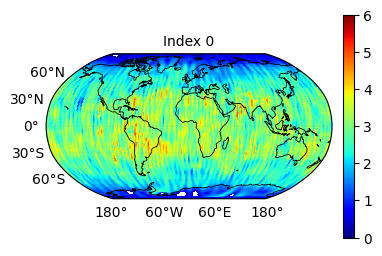

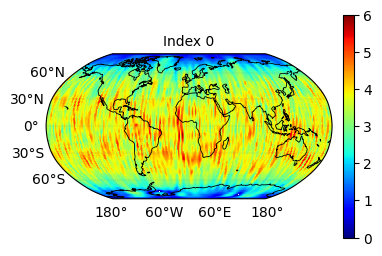

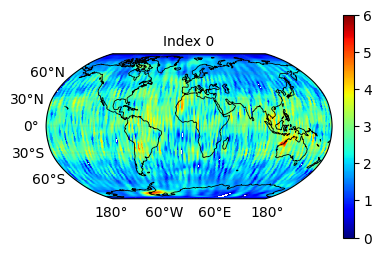

In [2]:
from sagea.error_assessment import tch, TCHMode

grid_err_tuple = tch(*grid_list, mode=TCHMode.OLS)

for grid_err in grid_err_tuple:
    grid_err.value *= 100
    grid_err.plot(
        vmin=0, vmax=6,
        projection=cartopy.crs.Robinson(),
        cmap="jet"
    )

# 3. Error assessment using TCA

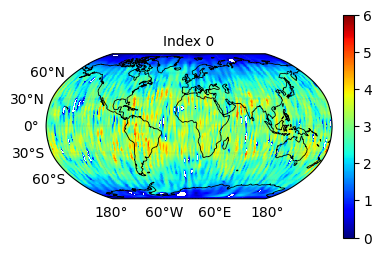

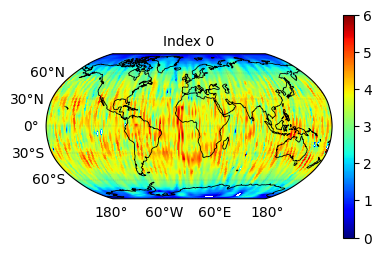

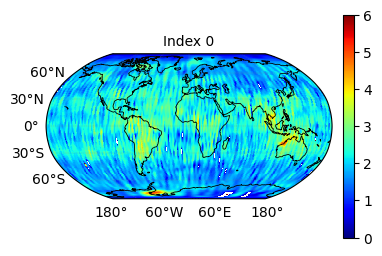

In [3]:
from sagea.error_assessment import tca, TCAMode

grid_err_tuple = tca(*grid_list, mode=TCAMode.CLASSIC)

for grid_err in grid_err_tuple:
    grid_err.value *= 100
    grid_err.plot(
        vmin=0, vmax=6,
        projection=cartopy.crs.Robinson(),
        cmap="jet"
    )